Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**


**Moons Classification Assessment**

---

### **Import Libraries**

In [144]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import itertools

from sklearn.datasets import make_moons
from sklearn.metrics import confusion_matrix


print(f'Tensorflow: {tf.__version__}\n',
      f'Pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}\n')


Tensorflow: 2.17.0
 Pandas: 2.2.3
 numpy: 1.26.4
 sklearn: 1.5.2



### **Prep Dataset**

In [145]:
n_samples = 1000

X, y = make_moons(n_samples,
                  noise=0.1,
                  random_state=42)

In [146]:
moons = pd.DataFrame({"X0": X[:, 0], 
                      "X1": X[:, 1], 
                      "label":y})

moons.head()

,X0,X1,label
0,-0.051470,0.444199,1
1,1.032017,-0.419741,1
2,0.867892,-0.254827,1
3,0.288851,-0.448669,1
4,-0.833439,0.535057,0


In [147]:
moons.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

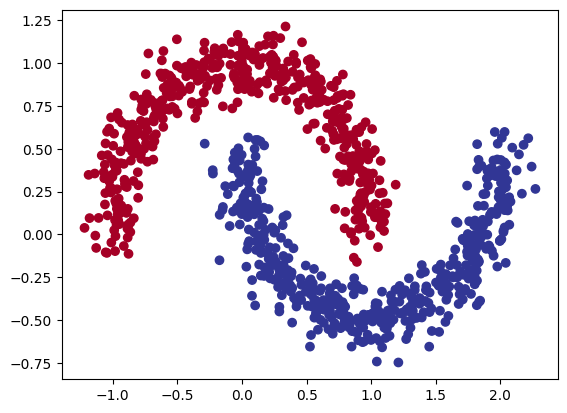

In [148]:
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [149]:
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

### **Find the Ideal Learning Rate**

In [150]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-5 * 10**(epoch/20))

history = model.fit(X_train, y_train, 
                    epochs=100,
                    callbacks=[lr_callback])  



Epoch 1/100


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


18/25 [====================>.........] - ETA: 0s - loss: 0.6935 - accuracy: 0.4618

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


25/25 [==============================] - 1s 7ms/step - loss: 0.6934 - accuracy: 0.4688 - lr: 1.0000e-05
Epoch 2/100
25/25 [==============================] - 0s 6ms/step - loss: 0.6924 - accuracy: 0.5412 - lr: 1.1220e-05
Epoch 3/100
25/25 [==============================] - 0s 5ms/step - loss: 0.6913 - accuracy: 0.5825 - lr: 1.2589e-05
Epoch 4/100
25/25 [==============================] - 0s 6ms/step - loss: 0.6900 - accuracy: 0.5875 - lr: 1.4125e-05
Epoch 5/100
25/25 [==============================] - 0s 6ms/step - loss: 0.6884 - accuracy: 0.6100 - lr: 1.5849e-05
Epoch 6/100
25/25 [==============================] - 0s 6ms/step - loss: 0.6867 - accuracy: 0.6150 - lr: 1.7783e-05
Epoch 7/100
25/25 [==============================] - 0s 6ms/step - loss: 0.6847 - accuracy: 0.6400 - lr: 1.9953e-05
Epoch 8/100
25/25 [==============================] - 0s 6ms/step - loss: 0.6821 - accuracy: 0.6850 - lr: 2.2387e-05
Epoch 9/100
25/25 [==============================] - 0s 6ms/step - loss: 0.6791 - ac

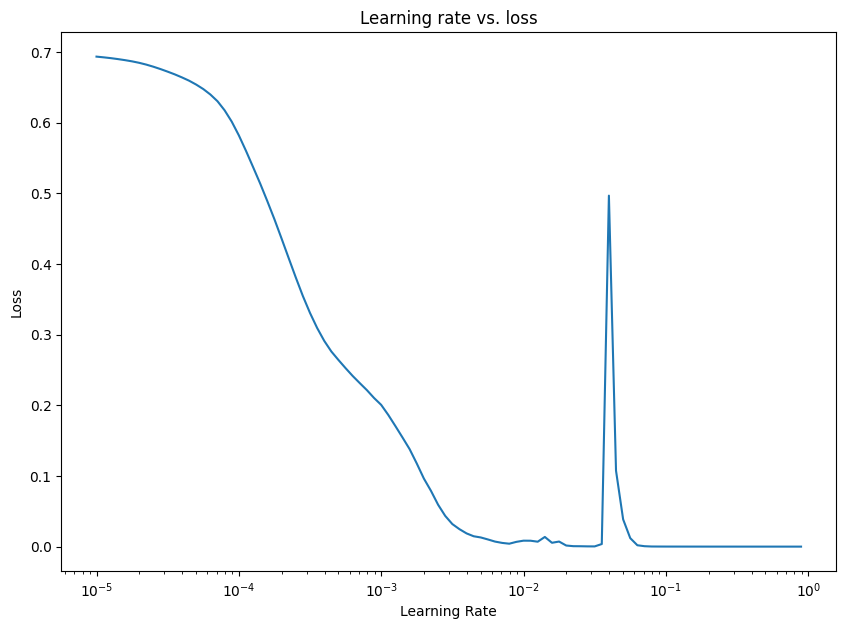

In [151]:
lrs = 1e-5 * (10 ** (np.arange(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history.history["loss"]) 
plt.xlabel("Learning Rate") 
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

as per the graph above, somewhere around ```learning_rate = 3e-3``` is the safest option.

### **Create Model with Optimal Learning Rate**

In [152]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=3.18e-3), #eyy 3.18
              metrics=['accuracy'])

history = model.fit(X_train, y_train, 
                    epochs=20,
                    validation_split=0.2)

Epoch 1/20


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

16/20 [=======================>......] - ETA: 0s - loss: 0.6184 - accuracy: 0.7793

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


20/20 [==============================] - 2s 20ms/step - loss: 0.5923 - accuracy: 0.7922 - val_loss: 0.3898 - val_accuracy: 0.9438
Epoch 2/20
20/20 [==============================] - 0s 8ms/step - loss: 0.3651 - accuracy: 0.8562 - val_loss: 0.1895 - val_accuracy: 0.9438
Epoch 3/20
20/20 [==============================] - 0s 8ms/step - loss: 0.2867 - accuracy: 0.8578 - val_loss: 0.1677 - val_accuracy: 0.9375
Epoch 4/20
20/20 [==============================] - 0s 8ms/step - loss: 0.2480 - accuracy: 0.8781 - val_loss: 0.1415 - val_accuracy: 0.9500
Epoch 5/20
20/20 [==============================] - 0s 9ms/step - loss: 0.2134 - accuracy: 0.8938 - val_loss: 0.1188 - val_accuracy: 0.9563
Epoch 6/20
20/20 [==============================] - 0s 8ms/step - loss: 0.1888 - accuracy: 0.9109 - val_loss: 0.0985 - val_accuracy: 0.9688
Epoch 7/20
20/20 [==============================] - 0s 8ms/step - loss: 0.1517 - accuracy: 0.9344 - val_loss: 0.0814 - val_accuracy: 0.9750
Epoch 8/20
20/20 [============

### **Display Results**

In [153]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    x_input = np.c_[xx.ravel(), yy.ravel()]
    
    y_pred = model.predict(x_input)
    
    if model.output_shape[-1] > 1: 
        print("doing multiclass classification...")
        
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print('doing binary classification...')
        y_pred = np.round(np.max(y_pred, axis=1)).reshape(xx.shape)
        
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

#### **Accuracy Graph**

Text(0, 0.5, 'Loss')

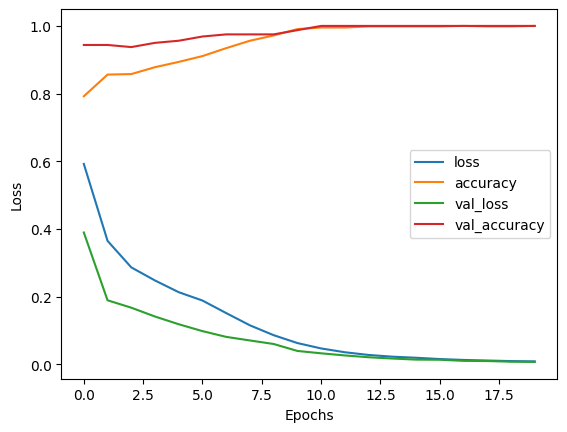

In [154]:
pd.DataFrame(history.history).plot()
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')

#### **Train vs Test Sets**

313/313 [==============================] - 1s 3ms/step
doing binary classification...
313/313 [==============================] - 1s 4ms/step
doing binary classification...


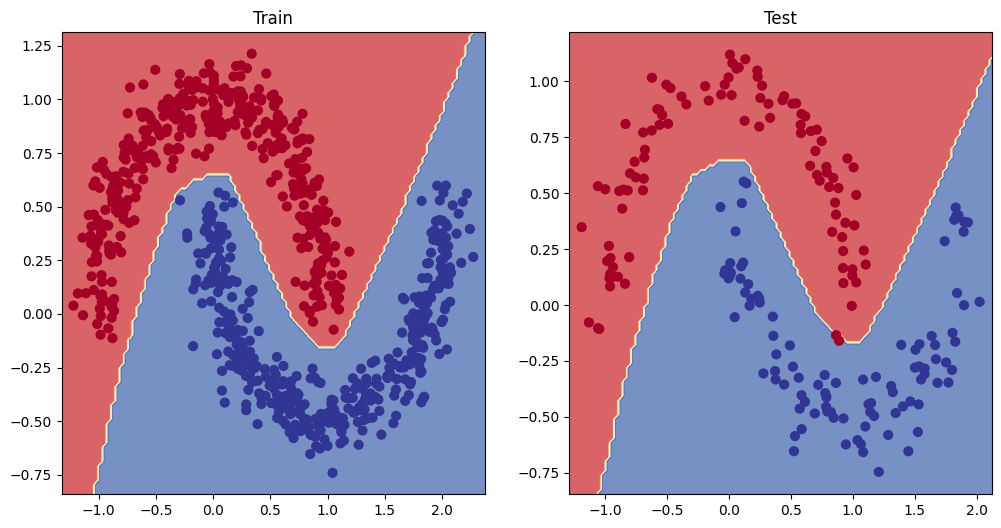

In [161]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title('Train')
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model, X_test, y_test)

#### **Confusion Matrix**

In [156]:
y_preds = model.predict(X_test)

confusion_matrix(y_test, tf.round(y_preds))

7/7 [==============================] - 0s 3ms/step


array([[99,  2],
       [ 0, 99]])

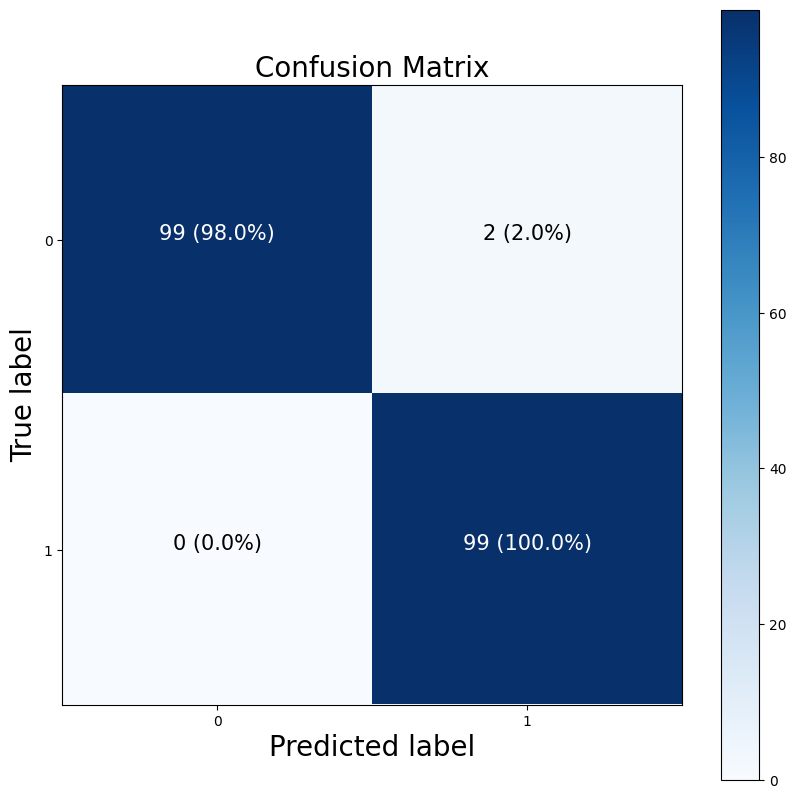

In [157]:
figsize = (10, 10)

cm = confusion_matrix(y_test, tf.round(y_preds))
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
n_classes = cm.shape[0]


fig, ax = plt.subplots(figsize=figsize)
cax = ax.matshow(cm, cmap=plt.cm.Blues) # https://matplotlib.org/3.2.0/api/_as_gen/matplotlib.axes.Axes.matshow.html
fig.colorbar(cax)

classes = False

if classes:
  labels = classes
else:
  labels = np.arange(cm.shape[0])

ax.set(title="Confusion Matrix",
       xlabel="Predicted label",
       ylabel="True label",
       xticks=np.arange(n_classes),
       yticks=np.arange(n_classes),
       xticklabels=labels,
       yticklabels=labels)

ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.title.set_size(20)

threshold = (cm.max() + cm.min()) / 2.

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
           horizontalalignment="center",
           color="white" if cm[i, j] > threshold else "black",
           size=15)